# Solar Power Generation Data Analysis
## Dataset Understanding and Exploration

A practical session on dataset understanding and exploration using real solar power generation data. 

### Learning Objectives:
- Understand the structure and characteristics of the datasets
- Perform exploratory data analysis (EDA) on solar power data
- Identify patterns, trends, and anomalies in renewable energy generation
- Learn data quality assessment techniques
- Visualize energy data effectively


In [1]:
# Import Required Libraries
import os
import pandas as pd
import numpy as np
from datetime import date, time
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Configure visualization settings
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Display options for better data viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

print("Libraries imported successfully")

Libraries imported successfully


## 1. Data Import and Initial Inspection

In this section, we'll import our solar power datasets and perform initial data inspection to understand:
- Dataset structure and dimensions
- Column names and data types
- Missing values
- Basic statistical summaries


### 1.1 Loading the Datasets

In [13]:
def load_data(data_folder="../data", generation_file="Plant_2_Generation_Data.csv", weather_file="Plant_2_Weather_Sensor_Data.csv", ):
        
    generation_path = os.path.join(data_folder, generation_file)
    weather_path = os.path.join(data_folder, weather_file)

    generation_df = pd.read_csv(generation_path)
    weather_df = pd.read_csv(weather_path)

    return generation_df, weather_df

generation_df, weather_df = load_data()

# Check datasets size
print(f"Generation Data Shape: {generation_df.shape}")
print(f"Weather Data Shape: {weather_df.shape}")

Generation Data Shape: (67698, 7)
Weather Data Shape: (3259, 6)


### 1.2 Initial Data Exploration

Let's examine the structure and basic characteristics of our datasets.

In [15]:
# Info
generation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67698 entries, 0 to 67697
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    67698 non-null  object 
 1   PLANT_ID     67698 non-null  int64  
 2   SOURCE_KEY   67698 non-null  object 
 3   DC_POWER     67698 non-null  float64
 4   AC_POWER     67698 non-null  float64
 5   DAILY_YIELD  67698 non-null  float64
 6   TOTAL_YIELD  67698 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.6+ MB


In [16]:
# Convert DATE_TIME to datetime format
generation_df['DATE_TIME'] = pd.to_datetime(generation_df['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# Create DAY and DAYTIME columns
generation_df['DAY'] = generation_df['DATE_TIME'].dt.date
generation_df['DAYTIME'] = generation_df['DATE_TIME'].dt.time

In [17]:
# Look at the dataset head
generation_df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,DAY,DAYTIME
0,2020-05-15,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06,2020-05-15,00:00:00
1,2020-05-15,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09,2020-05-15,00:00:00
2,2020-05-15,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09,2020-05-15,00:00:00
3,2020-05-15,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06,2020-05-15,00:00:00
4,2020-05-15,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07,2020-05-15,00:00:00


In [18]:
# Summary statistics
generation_df.describe(include='all')

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,DAY,DAYTIME
count,67698,67698.0,67698,67698.000000,67698.000000,67698.000000,6.769800e+04,67698,67698
unique,NaN,NaN,22,NaN,NaN,NaN,NaN,34,96
top,NaN,NaN,81aHJ1q11NBPMrL,NaN,NaN,NaN,NaN,2020-05-16,21:00:00
freq,NaN,NaN,3259,NaN,NaN,NaN,NaN,2112,716
mean,2020-06-01 10:44:33.650625024,4136001.0,NaN,246.701961,241.277825,3294.890295,6.589448e+08,NaN,NaN
min,2020-05-15 00:00:00,4136001.0,NaN,0.000000,0.000000,0.000000,0.000000e+00,NaN,NaN
25%,2020-05-23 21:00:00,4136001.0,NaN,0.000000,0.000000,272.750000,1.996494e+07,NaN,NaN
50%,2020-06-01 23:00:00,4136001.0,NaN,0.000000,0.000000,2911.000000,2.826276e+08,NaN,NaN
75%,2020-06-09 23:30:00,4136001.0,NaN,446.591667,438.215000,5534.000000,1.348495e+09,NaN,NaN
max,2020-06-17 23:45:00,4136001.0,NaN,1420.933333,1385.420000,9873.000000,2.247916e+09,NaN,NaN


##### We have 22 sources for 34 days and 96 sample per day (quarter of hour)

##### What about the weather dataset?

In [19]:
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')
weather_df['DAY'] = weather_df['DATE_TIME'].dt.date
weather_df['DAYTIME'] = weather_df['DATE_TIME'].dt.time
weather_df.describe(include='all')

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DAY,DAYTIME
count,3259,3259.0,3259,3259.000000,3259.000000,3259.000000,3259,3259
unique,NaN,NaN,1,NaN,NaN,NaN,34,96
top,NaN,NaN,iq8k7ZNt4Mwm3w0,NaN,NaN,NaN,2020-05-16,00:00:00
freq,NaN,NaN,3259,NaN,NaN,NaN,96,34
mean,2020-06-01 00:04:35.053697536,4136001.0,NaN,28.069400,32.772408,0.232737,NaN,NaN
min,2020-05-15 00:00:00,4136001.0,NaN,20.942385,20.265123,0.000000,NaN,NaN
25%,2020-05-23 12:07:30,4136001.0,NaN,24.602135,23.716881,0.000000,NaN,NaN
50%,2020-06-01 00:00:00,4136001.0,NaN,26.981263,27.534606,0.019040,NaN,NaN
75%,2020-06-09 12:07:30,4136001.0,NaN,31.056757,40.480653,0.438717,NaN,NaN
max,2020-06-17 23:45:00,4136001.0,NaN,39.181638,66.635953,1.098766,NaN,NaN


##### In weathern dataset we have 1 source for 34 days and 96 sample per day

## 2. Univariate Data Exploration

In this section, we'll explore individual variables to understand their distributions, identify outliers, and gain insights into the characteristics of each feature.

### 2.1 Timestamp: do we have a complete dataset?

Let's examine the completeness of the dataset


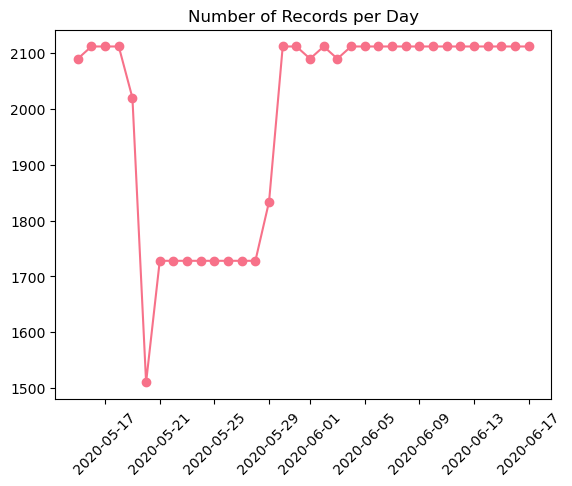

In [20]:
# Plot number of records per day
records_per_day = generation_df['DAY'].value_counts().sort_index()
plt.plot(records_per_day.index, records_per_day.values, marker='o')
plt.title('Number of Records per Day')
plt.xticks(rotation=45)
plt.show()

##### Some day we don't have all the data, it should ben 22*96 = 2112 sample per day

In [21]:
# How many source with complete data?
total_sample_per_day = 96
source_dataquality = generation_df.groupby(['DAY','SOURCE_KEY'])[['DAYTIME']].count().rename({'DAYTIME': 'sample_completeness'})
source_dataquality['sample_completeness'] = round(source_dataquality/total_sample_per_day * 100, 2)
source_dataquality.head()

DAYTIME  sample_completeness
DAY        SOURCE_KEY                                   
2020-05-15 4UPUqMRk7TRMgml       95                98.96
           81aHJ1q11NBPMrL       95                98.96
           9kRcWv60rDACzjR       95                98.96
           Et9kgGMDl729KT4       95                98.96
           IQ2d7wF4YD8zU1Q       95                98.96

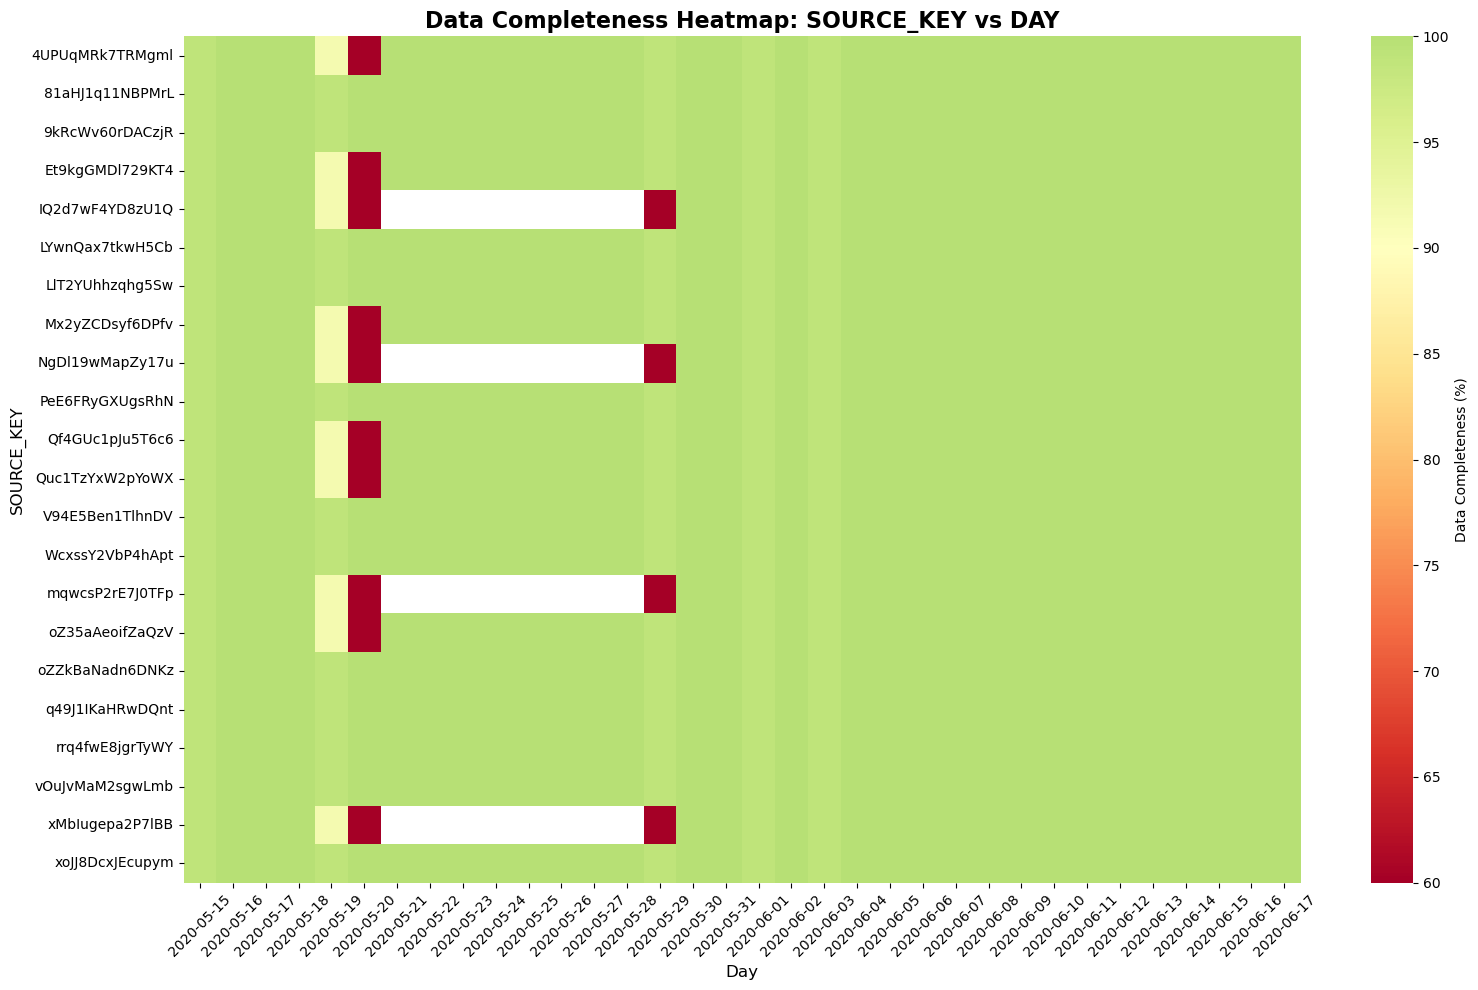


=== DATA COMPLETENESS SUMMARY ===
Overall average completeness: 98.55%
Minimum completeness: 32.29%
Maximum completeness: 100.00%
Number of 100% complete combinations: 596
Number of missing combinations: 32


In [22]:
# Plot a heatmap with SOURCE_KEY on rows and DAY on cols
heatmap_data = source_dataquality.reset_index().pivot(index='SOURCE_KEY', columns='DAY', values='sample_completeness')

# Create the heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data, 
            annot=False,  # Set to True if you want to show values in cells
            cmap='RdYlGn',  # Red-Yellow-Green colormap (red=bad, green=good)
            center=90,  # Center the colormap at 75% (middle of 50-100 range)
            vmin=60, vmax=100,  # Set range from 50% to 100%
            cbar_kws={'label': 'Data Completeness (%)'})

plt.title('Data Completeness Heatmap: SOURCE_KEY vs DAY', fontsize=16, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('SOURCE_KEY', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== DATA COMPLETENESS SUMMARY ===")
print(f"Overall average completeness: {heatmap_data.mean().mean():.2f}%")
print(f"Minimum completeness: {heatmap_data.min().min():.2f}%")
print(f"Maximum completeness: {heatmap_data.max().max():.2f}%")
print(f"Number of 100% complete combinations: {(heatmap_data == 100).sum().sum()}")
print(f"Number of missing combinations: {heatmap_data.isna().sum().sum()}")

##### In plant 2 we observe two different clusters of sources

For the univariate analysis is important to isolate the two different behaviours, we'll analyse split the dataset and continue the analysis of complete source_key(s)

The dataset is public, it would be a great excercise to explore the other set of sources by your self!


In [23]:
# Select SOURCE_KEYs with more than 98% average completeness
completeness_threshold = 98.0

# Calculate average completeness per SOURCE_KEY across all days
source_avg_completeness = heatmap_data.mean(axis=1)  # axis=1 means average across columns (days)

# Filter sources with more than 98% average completeness
high_quality_sources = list(source_avg_completeness[source_avg_completeness > completeness_threshold].index)

print(f"=== SOURCE_KEYs WITH MORE THAN {completeness_threshold}% AVERAGE COMPLETENESS ===")
print(f"Number of high-quality sources: {len(high_quality_sources)} out of {len(source_avg_completeness)}")

=== SOURCE_KEYs WITH MORE THAN 98.0% AVERAGE COMPLETENESS ===
Number of high-quality sources: 12 out of 22


In [24]:
# Filter only high qualtity data
generation_df = generation_df[generation_df.SOURCE_KEY.isin(high_quality_sources)]

### 2.2 Distribution of dataset feature

Now we focus on univariate distribution of other features

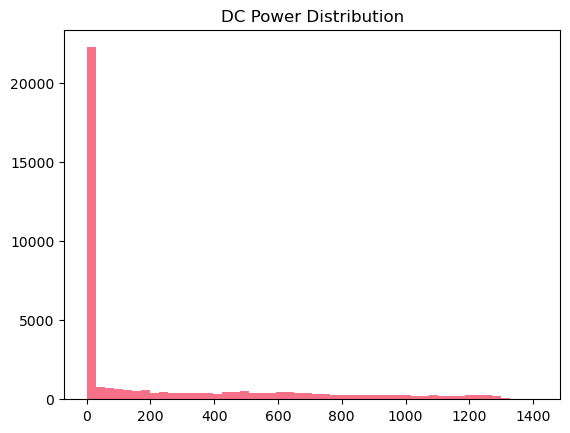

In [25]:
# A hist (histogram) plot of DC_POWER
plt.hist(generation_df['DC_POWER'], bins=50)
plt.title("DC Power Distribution")
plt.show()

Value 0 is very frequent but it's something we expect, during night time there is no generation. We'll check later if it is correlated with daytime and irradiation

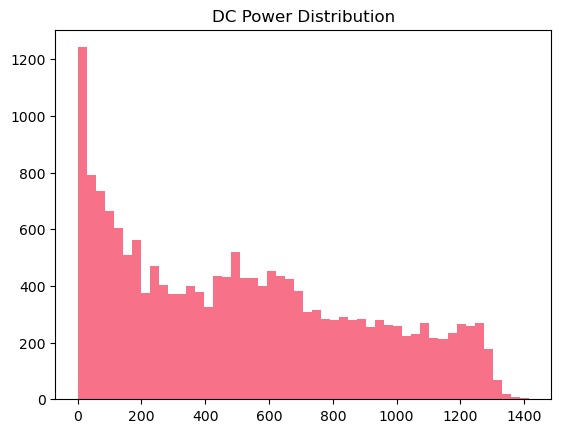

In [26]:
# A hist (histogram) plot of DC_POWER where power is not null
plt.hist(generation_df.loc[generation_df['DC_POWER']>0]['DC_POWER'], bins=50)
plt.title("DC Power Distribution")
plt.show()

We don't see any outlier, we can use a boxplot to visulize the distribution outliers

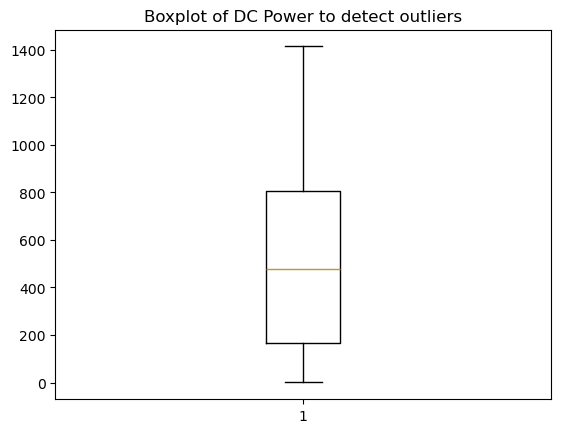

In [27]:
# Box Plot of DC_POWER where power is not null
plt.title("Boxplot of DC Power to detect outliers")
plt.boxplot(generation_df.loc[generation_df.DC_POWER>0]['DC_POWER'])
plt.show()

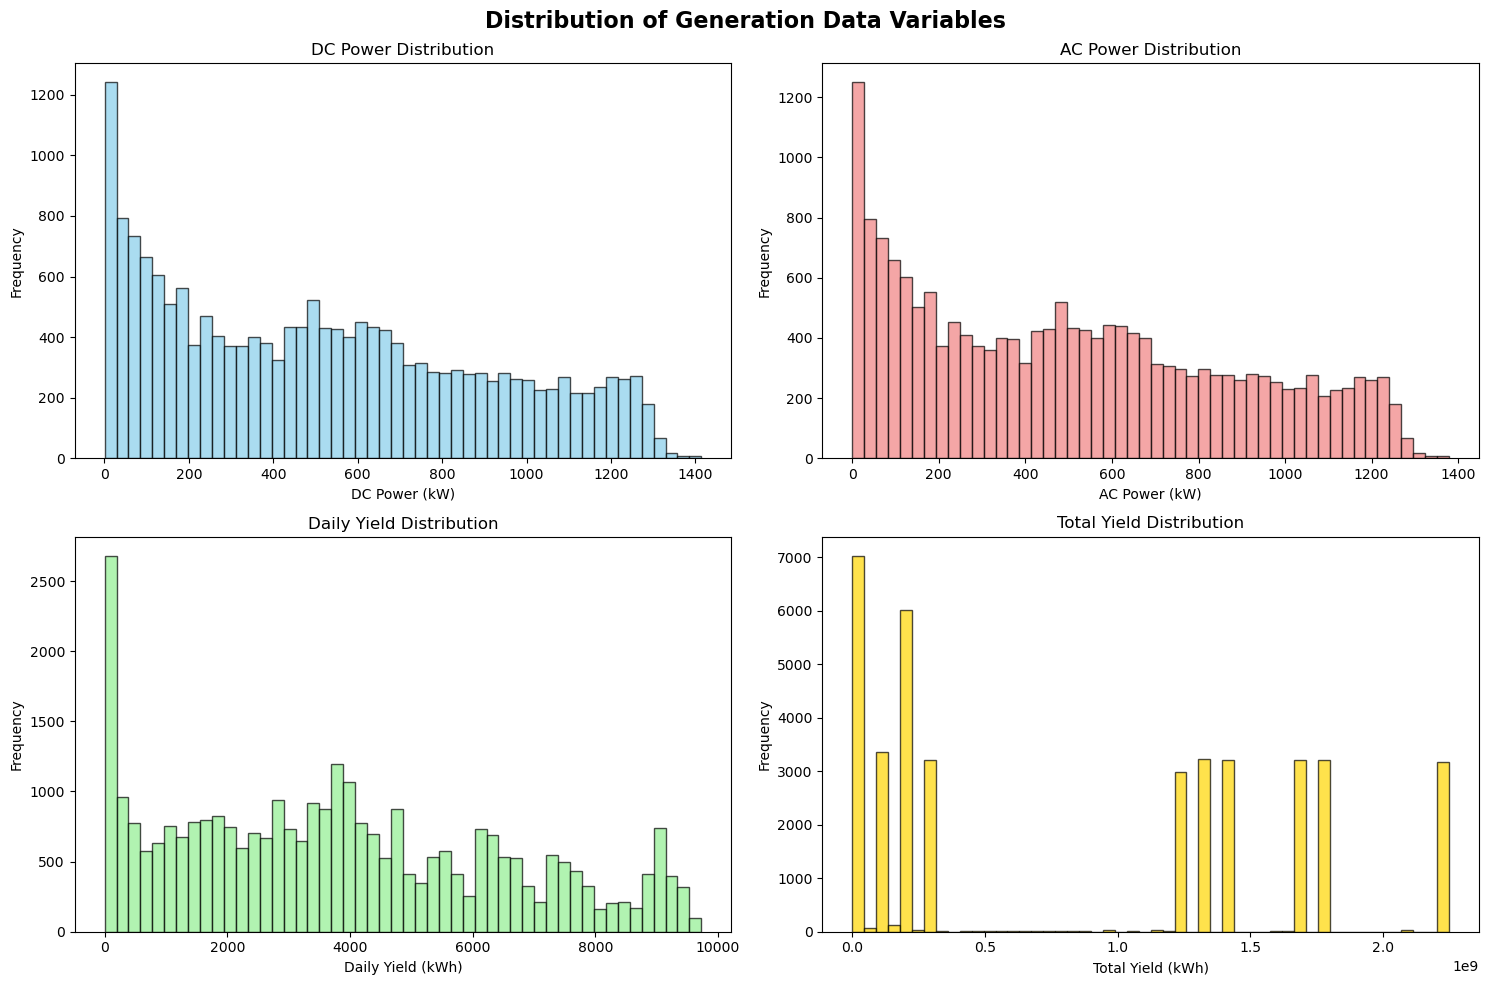

In [28]:
# Create histograms for key numerical variables in generation data
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Generation Data Variables', fontsize=16, fontweight='bold')

# DC Power distribution
axes[0, 0].hist(generation_df.loc[generation_df.DC_POWER>0]['DC_POWER'], bins=50, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('DC Power Distribution')
axes[0, 0].set_xlabel('DC Power (kW)')
axes[0, 0].set_ylabel('Frequency')

# AC Power distribution
axes[0, 1].hist(generation_df.loc[generation_df.AC_POWER>0]['AC_POWER'], bins=50, color='lightcoral', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('AC Power Distribution')
axes[0, 1].set_xlabel('AC Power (kW)')
axes[0, 1].set_ylabel('Frequency')

# Daily Yield distribution
axes[1, 0].hist(generation_df.loc[generation_df.DAILY_YIELD>0]['DAILY_YIELD'], bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Daily Yield Distribution')
axes[1, 0].set_xlabel('Daily Yield (kWh)')
axes[1, 0].set_ylabel('Frequency')

# Total Yield distribution
axes[1, 1].hist(generation_df['TOTAL_YIELD'], bins=50, color='gold', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Total Yield Distribution')
axes[1, 1].set_xlabel('Total Yield (kWh)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

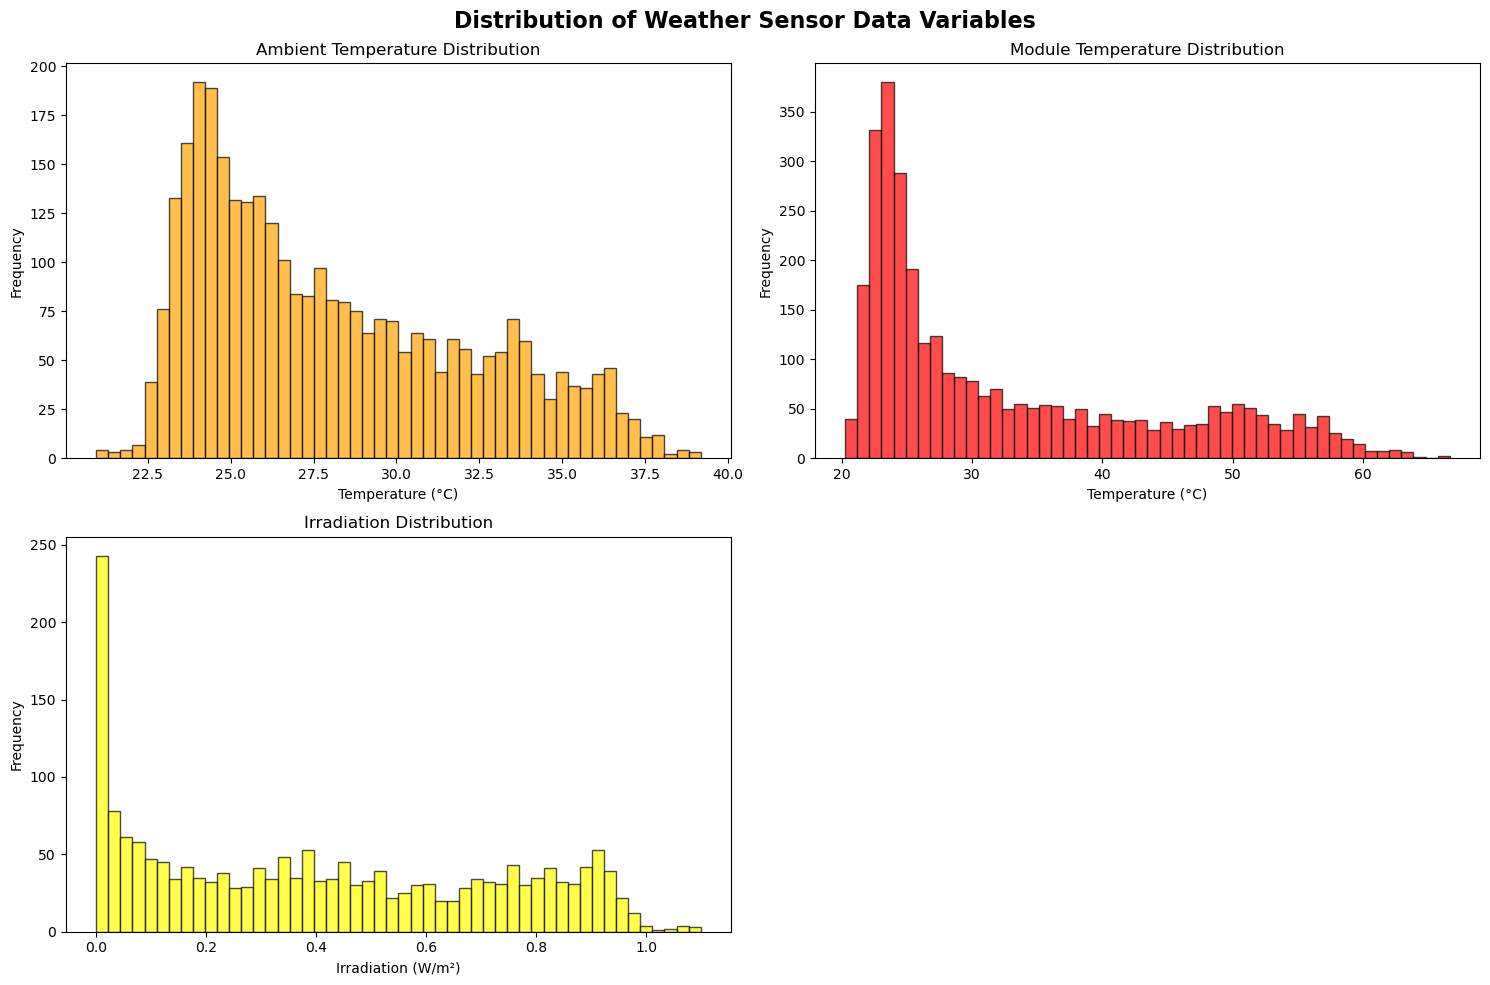

In [29]:
# Create histograms for weather sensor data
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Weather Sensor Data Variables', fontsize=16, fontweight='bold')

# Ambient Temperature distribution
axes[0, 0].hist(weather_df['AMBIENT_TEMPERATURE'], bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Ambient Temperature Distribution')
axes[0, 0].set_xlabel('Temperature (°C)')
axes[0, 0].set_ylabel('Frequency')

# Module Temperature distribution
axes[0, 1].hist(weather_df['MODULE_TEMPERATURE'], bins=50, color='red', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Module Temperature Distribution')
axes[0, 1].set_xlabel('Temperature (°C)')
axes[0, 1].set_ylabel('Frequency')

# Irradiation distribution
axes[1, 0].hist(weather_df.loc[weather_df.IRRADIATION>0]['IRRADIATION'], bins=50, color='yellow', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Irradiation Distribution')
axes[1, 0].set_xlabel('Irradiation (W/m²)')
axes[1, 0].set_ylabel('Frequency')

# Remove the empty subplot
axes[1, 1].remove()

plt.tight_layout()
plt.show()

## 3 Multivariate exploration

In this section, we'll explore relationships between variables to understand:
- Correlations between power generation and weather variables
- Time-based patterns
- Relationships between DC and AC power


### 3.1 Correlation Analysis

Let's start by examining the correlation between different variables.

We merge the two datasets, plant2 and weather2. First we group all the single inverters (SOURCE_KEY) by DATETIME, then we merge with the weather data using as common key the DATETIME column.


In [30]:
# Merge generation and weather data for correlation analysis
# First, aggregate generation data by datetime (sum across all sources)
print(f"Dataframe shape size before aggregation: {generation_df.shape}")
generation_agg = generation_df.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER', 'DAILY_YIELD']].sum().reset_index()

print(f"Dataframe shape size before merge: {generation_agg.shape}")
# Merge with weather data
merged_data = pd.merge(generation_agg, weather_df, on='DATE_TIME', how='inner')

print(f"Dataframe shape size after merge: {merged_data.shape}")

Dataframe shape size before aggregation: (39108, 9)
Dataframe shape size before merge: (3259, 4)
Dataframe shape size after merge: (3259, 11)


Alwayes check your data frame after merge!

In [32]:
merged_data.isnull().sum()

DATE_TIME              0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
DAY                    0
DAYTIME                0
dtype: int64

In [33]:
# Calculate correlation matrix for numerical variables
numerical_cols = ['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 
                  'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
correlation_matrix = merged_data[numerical_cols].corr()
correlation_matrix

,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DC_POWER,1.000000,0.999996,-0.057137,0.640622,0.846931,0.887983
AC_POWER,0.999996,1.000000,-0.057254,0.640379,0.846398,0.887363
DAILY_YIELD,-0.057137,-0.057254,1.000000,0.436563,0.096878,-0.097882
AMBIENT_TEMPERATURE,0.640622,0.640379,0.436563,1.000000,0.847273,0.667639
MODULE_TEMPERATURE,0.846931,0.846398,0.096878,0.847273,1.000000,0.946886
IRRADIATION,0.887983,0.887363,-0.097882,0.667639,0.946886,1.000000


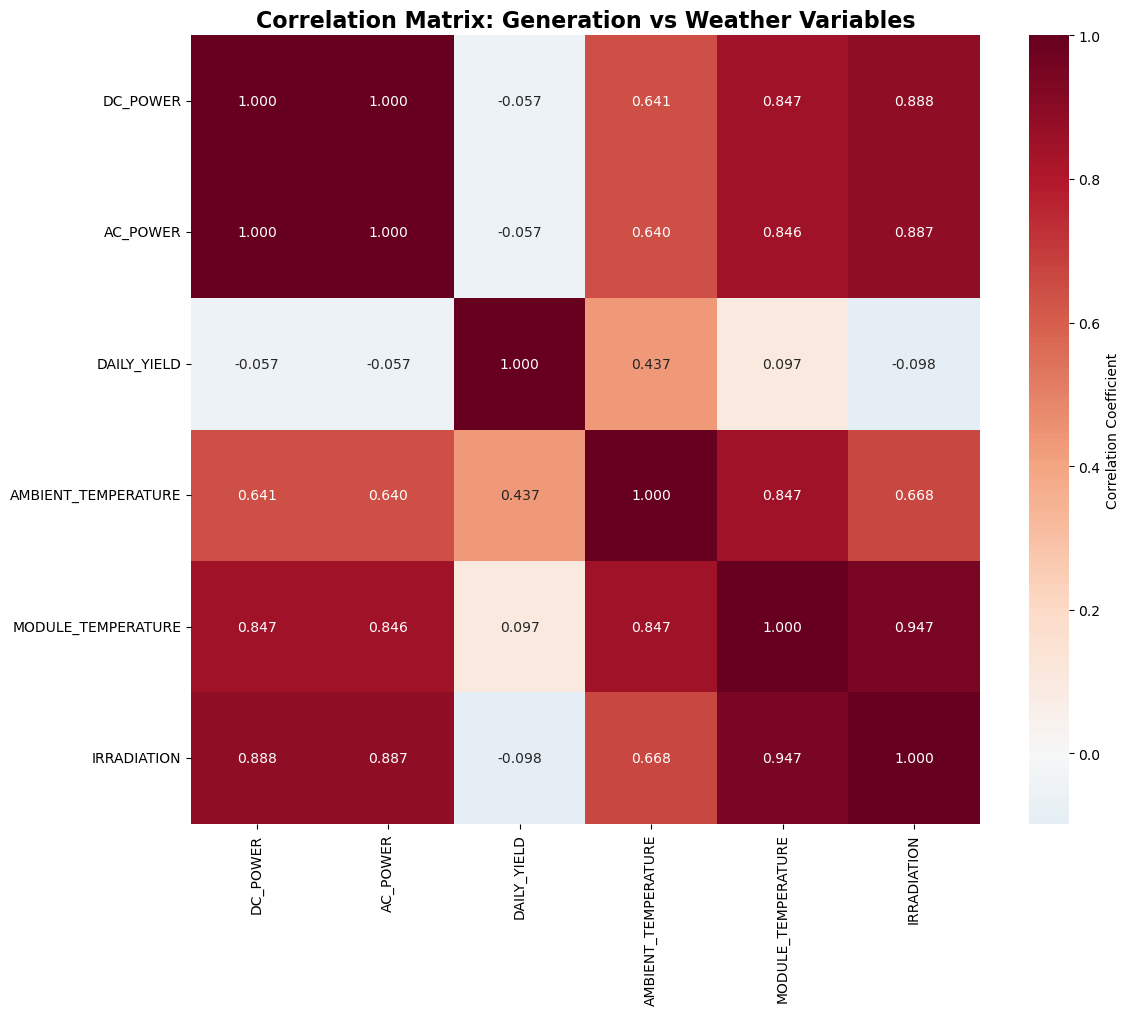

In [34]:
# Create correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix: Generation vs Weather Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Scatter Plot Analysis

Let's visualize the relationships between key variables using scatter plots.



#### 3.2.1 Irradiation vs Generated Power

First we visualize the reletionship between Irradiation and Generation at the inverter input

IRRADIATION -> _panels_ -> DC_POWER -> _inverter_ -> AC_POWER

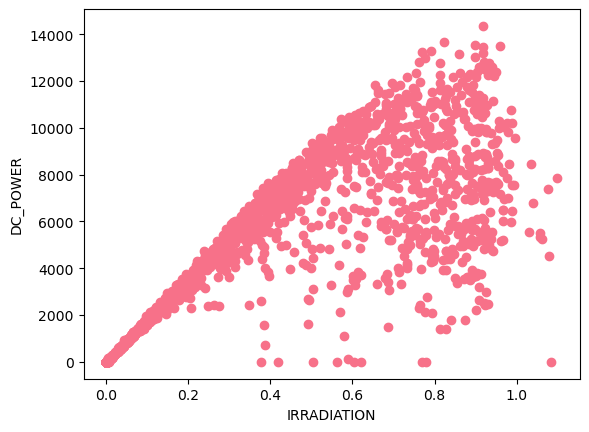

In [35]:
# Scatter plot of IRRADIATION and DC_POWER
plt.scatter(merged_data['IRRADIATION'], merged_data['DC_POWER'])
plt.xlabel('IRRADIATION')
plt.ylabel('DC_POWER')
plt.show()

At low irradiation there is a clear linear dependency, the more irradiation grows the less clear is the dependency. 

It might be caused by high temperature?

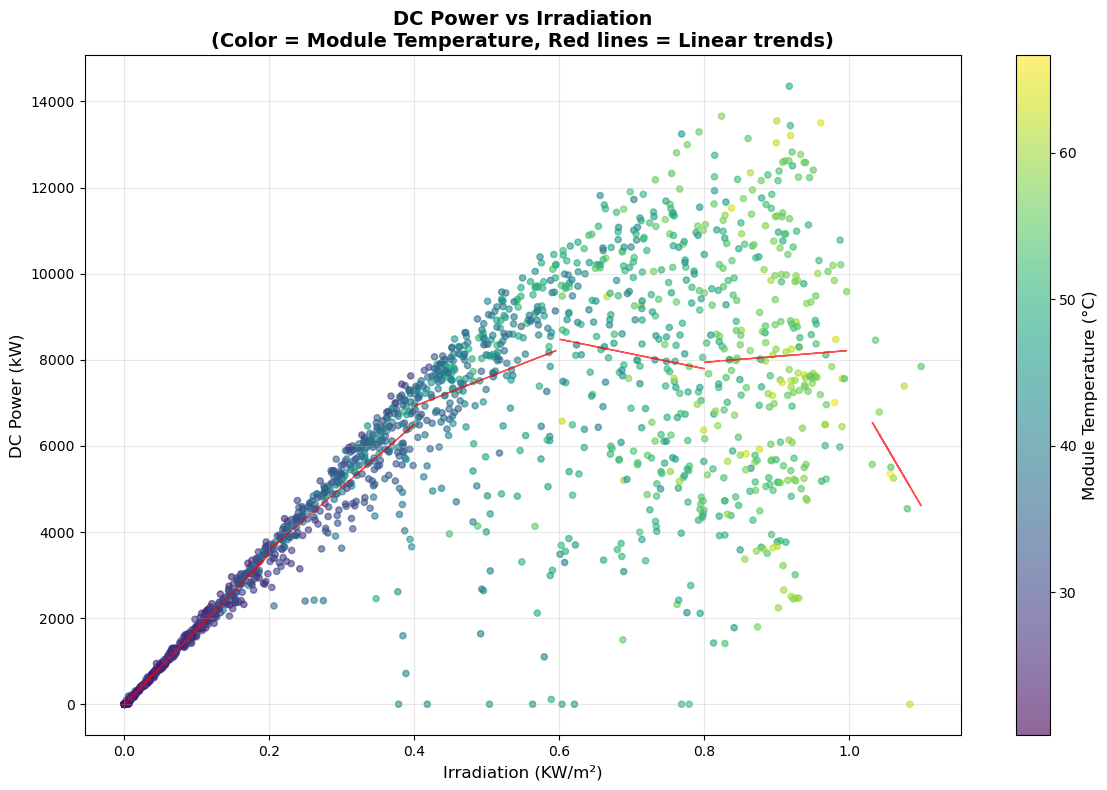

In [36]:
# Scatter plot of IRRADIATION and DC_POWER with MODULE_TEMPERATURE color coding
plt.figure(figsize=(12, 8))

# Create scatter plot with color coding by MODULE_TEMPERATURE
scatter = plt.scatter(merged_data['IRRADIATION'], merged_data['DC_POWER'], 
                     c=merged_data['MODULE_TEMPERATURE'], 
                     cmap='viridis', 
                     alpha=0.6, 
                     s=20)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Module Temperature (°C)', fontsize=12)

# Fit linear trend lines every 0.2 space on irradiation
irradiation_min = merged_data['IRRADIATION'].min()
irradiation_max = merged_data['IRRADIATION'].max()

# Create bins with 0.2 spacing
bin_edges = np.arange(irradiation_min, irradiation_max + 0.2, 0.2)

# Fit trend lines for each bin
for i in range(len(bin_edges) - 1):
    # Filter data for current irradiation bin
    mask = (merged_data['IRRADIATION'] >= bin_edges[i]) & (merged_data['IRRADIATION'] < bin_edges[i + 1])
    bin_data = merged_data[mask]
    
    # Only fit if we have enough data points
    if len(bin_data) >= 5:
        # Fit linear regression
        x = bin_data['IRRADIATION']
        y = bin_data['DC_POWER']
        
        # Calculate linear fit
        coeffs = np.polyfit(x, y, 1)
        trend_line = np.polyval(coeffs, x)
        
        # Plot trend line
        plt.plot(x, trend_line, 'r-', alpha=0.7, linewidth=1)

plt.xlabel('Irradiation (KW/m²)', fontsize=12)
plt.ylabel('DC Power (kW)', fontsize=12)
plt.title('DC Power vs Irradiation\n(Color = Module Temperature, Red lines = Linear trends)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

It's clear there is a strong relation with module temperature, above 50 degree it's seems to reach a maximum point and more irradiation don't generate more power.
But why is that? Always remember "correlation does not imply causation"


#### 3.2.2  Module temperature vs Ambient Temperature
We can explore a little bit more the temperature features, what's the realtion betweeen module and ambient temperature?

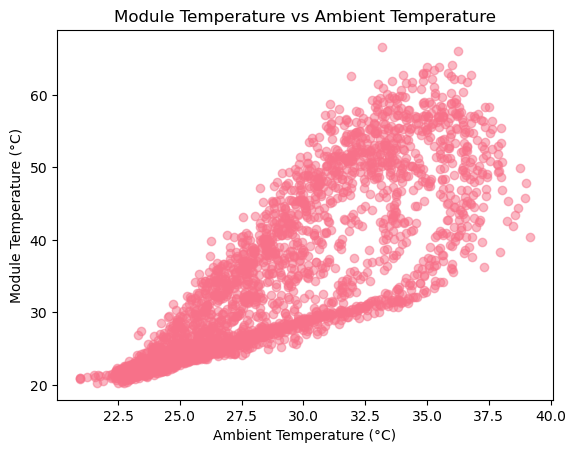

In [37]:
# Scatter plot of MODULE_TEMPERATURE vs AMBIENT_TEMPERATURE
plt.scatter(merged_data['AMBIENT_TEMPERATURE'], merged_data['MODULE_TEMPERATURE'], alpha=0.5)
plt.title("Module Temperature vs Ambient Temperature")
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("Module Temperature (°C)")
plt.show()

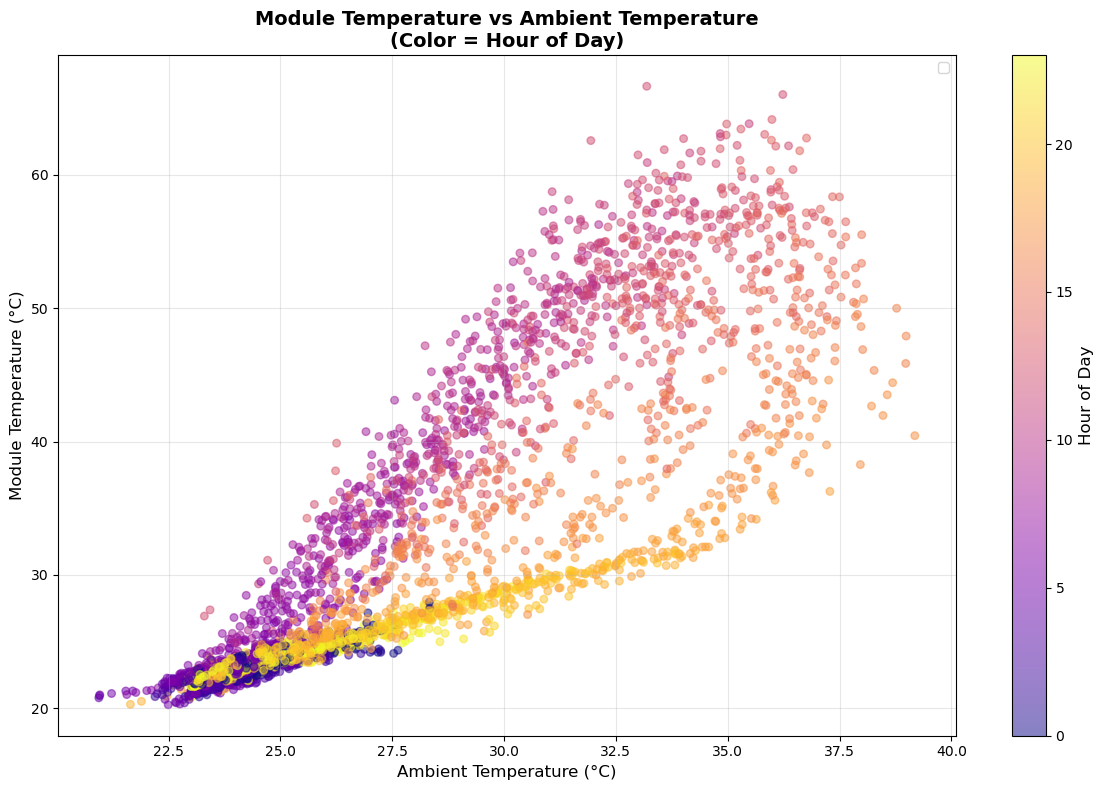

=== TEMPERATURE ANALYSIS ===
Correlation between Ambient and Module Temperature: 0.847
Peak temperature difference occurs at 12:00 with 19.5°C difference
Average Ambient Temperature: 28.1°C
Average Module Temperature: 32.8°C
Average Temperature Difference: 4.7°C


In [38]:
# Scatter plot of MODULE_TEMPERATURE vs AMBIENT_TEMPERATURE with DAYTIME color coding
plt.figure(figsize=(12, 8))

# Extract hour from DATE_TIME for color coding
merged_data['HOUR'] = merged_data['DATE_TIME'].dt.hour

# Create scatter plot with color coding by hour of day
scatter = plt.scatter(merged_data['AMBIENT_TEMPERATURE'], 
                     merged_data['MODULE_TEMPERATURE'], 
                     c=merged_data['HOUR'], 
                     cmap='plasma', 
                     alpha=0.5, 
                     s=30)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Hour of Day', fontsize=12)

# Add labels and title
plt.xlabel("Ambient Temperature (°C)", fontsize=12)
plt.ylabel("Module Temperature (°C)", fontsize=12)
plt.title("Module Temperature vs Ambient Temperature\n(Color = Hour of Day)", fontsize=14, fontweight='bold')

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()

# Print some insights about the temperature relationship
print("=== TEMPERATURE ANALYSIS ===")
temp_correlation = merged_data['AMBIENT_TEMPERATURE'].corr(merged_data['MODULE_TEMPERATURE'])
print(f"Correlation between Ambient and Module Temperature: {temp_correlation:.3f}")

# Temperature difference by hour
temp_diff_by_hour = merged_data.groupby('HOUR').apply(lambda x: (x['MODULE_TEMPERATURE'] - x['AMBIENT_TEMPERATURE']).mean())
peak_diff_hour = temp_diff_by_hour.idxmax()
peak_diff = temp_diff_by_hour.max()
print(f"Peak temperature difference occurs at {peak_diff_hour}:00 with {peak_diff:.1f}°C difference")

# Average temperatures
print(f"Average Ambient Temperature: {merged_data['AMBIENT_TEMPERATURE'].mean():.1f}°C")
print(f"Average Module Temperature: {merged_data['MODULE_TEMPERATURE'].mean():.1f}°C")
print(f"Average Temperature Difference: {(merged_data['MODULE_TEMPERATURE'] - merged_data['AMBIENT_TEMPERATURE']).mean():.1f}°C")

With a simple addition the cloud of fuzzy point is now clear and describe a phisical phenomenum (have a look at Hysteresis https://en.wikipedia.org/wiki/Hysteresis)

The module is very fast at heating up in the morning, then there is a vertical drop in module temperature when ambient is cooling down and at the end of the day they have the same pace. 

This kind of understanding is important in the planning phase of new plants.


### 3.3 Time-based Analysis

To better understand phenomenum like the one above and many more interesting insight from our plant a time-based analysis is what we need.

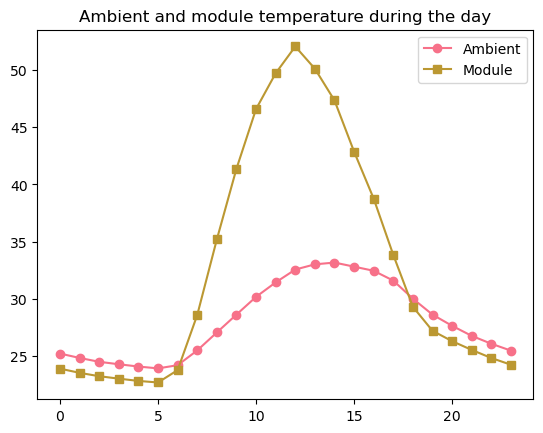

In [39]:
# Time-based analysis: Module temperature and Ambient temperature during the day
hourly_temp = merged_data.groupby('HOUR')[['MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE']].mean()
plt.plot(hourly_temp.index, hourly_temp.AMBIENT_TEMPERATURE, label='Ambient', marker='o')
plt.plot(hourly_temp.index, hourly_temp.MODULE_TEMPERATURE, label='Module', marker='s')
plt.title('Ambient and module temperature during the day')
plt.legend()
plt.show()


We can use lineplot for more interesting time-based analysis, for example, what's the relation between irradiance and DC_POWER?

<Figure size 1400x1000 with 0 Axes>

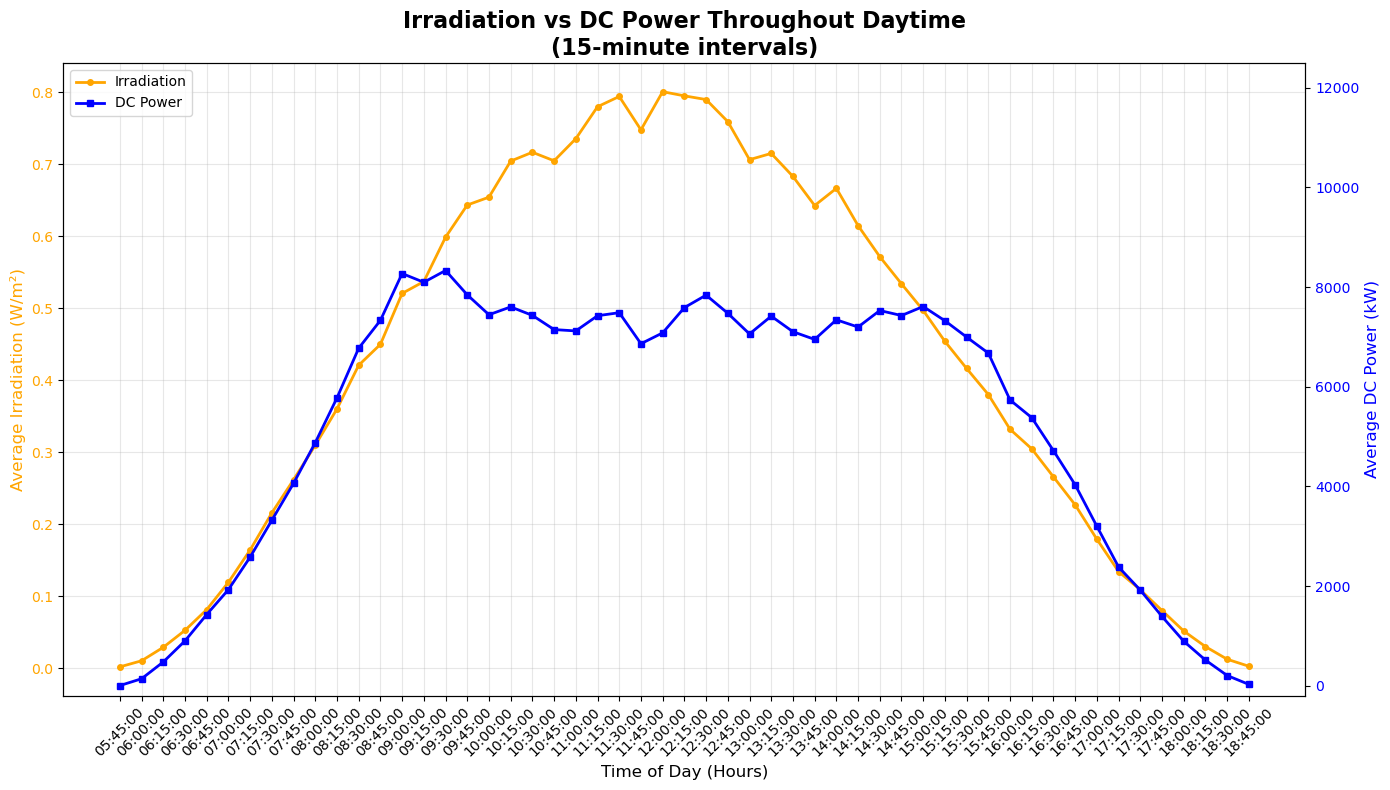

In [40]:
# Analyze the relationship between IRRADIATION and DC_POWER throughout daytime
# Filter for daylight hours (when DC_POWER > 0)
daylight_data = merged_data[merged_data['DC_POWER'] > 0].copy()
daylight_data = daylight_data.groupby('DAYTIME')[['IRRADIATION', 'DC_POWER']].mean().reset_index()
daylight_data.sort_values(by='DAYTIME', inplace=True)
daylight_data['DAYTIME'] = daylight_data['DAYTIME'].astype(str)

# Create the line plot
plt.figure(figsize=(14, 10))

# Create subplot with two y-axes
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot IRRADIATION on the left y-axis
color = 'orange'
ax1.set_xlabel('Time of Day (Hours)', fontsize=12)
ax1.set_xticklabels(daylight_data['DAYTIME'], rotation=45)
ax1.set_ylabel('Average Irradiation (KW/m²)', color=color, fontsize=12)
line1 = ax1.plot(daylight_data['DAYTIME'], daylight_data['IRRADIATION'], 
                 color=color, linewidth=2, marker='o', markersize=4, label='Irradiation')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Create second y-axis for DC_POWER
ax2 = ax1.twinx()
color = 'blue'
ax2.set_ylabel('Average DC Power (kW)', color=color, fontsize=12)
line2 = ax2.plot(daylight_data['DAYTIME'], daylight_data['DC_POWER'], 
                 color=color, linewidth=2, marker='s', markersize=4, label='DC Power')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(-200, daylight_data['DC_POWER'].max() * 1.5)

# Add title and legend
plt.title('Irradiation vs DC Power Throughout Daytime\n(15-minute intervals)', fontsize=16, fontweight='bold')

# Create combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

Interesting discovery! The DC_POWER doesn't max-out at the maximum peak of irradiance, what can be the reason?

Inverters are usually not built for maximum production peak and this produce the clipping. 
Be awere! The clipping phenomenum usually is present at the DC/AC conversion. That is valid for domestic PV, for industial ones there could be control systems that clip the power at the entrance of the inverter for machinery safety reason. 

This is something worth to deep understand, we can perform the analysis for any single inverter and we should investigate it in the next business understanding phase.

********************************************************************************

Now we concentrate the analysis on the last part, the DC/AC conversion. 

It's known that there is some losses at this point, we try to understand the aggregated behaviour


In [ ]:
# Create two side-by-side plots for DC/AC power analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('DC Power vs AC Power: Time Series and Relationship Analysis', fontsize=16, fontweight='bold')

# First plot: Line plot of DC_POWER and AC_POWER during daytime
daylight_data = merged_data[merged_data['DC_POWER'] > 0].copy()
daylight_data['DAYTIME'] = daylight_data['DAYTIME'].astype(str)

# Group by time and calculate averages
hourly_power = daylight_data.groupby('DAYTIME')[['DC_POWER', 'AC_POWER']].mean()

axes[0].plot(hourly_power.index, hourly_power['DC_POWER'], 
             marker='o', linewidth=2, label='DC Power', color='blue', markersize=6)
axes[0].plot(hourly_power.index, hourly_power['AC_POWER'], 
             marker='s', linewidth=2, label='AC Power', color='red', markersize=6)

axes[0].set_xlabel('Hour of Day', fontsize=12)
axes[0].set_ylabel('Average Power (kW)', fontsize=12)
axes[0].set_title('DC and AC Power During Daytime', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticklabels(hourly_power.index, rotation=45)

# Second plot: Scatter plot with linear trend
axes[1].scatter(daylight_data['DC_POWER'], daylight_data['AC_POWER'], 
                alpha=0.6, color='blue', s=5, label='Data points')

# Add ideal conversion line (100% efficiency)
max_power = max(daylight_data['DC_POWER'].max(), daylight_data['AC_POWER'].max())
axes[1].plot([0, max_power], [0, max_power], 'r--', linewidth=2, 
             label='Ideal Conversion (100% Efficiency)')

axes[1].set_xlabel('DC Power (kW)', fontsize=12)
axes[1].set_ylabel('AC Power (kW)', fontsize=12)
axes[1].set_title('DC Power vs AC Power Relationship', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


As expected there is some loss in the conversion, let's compute the numbers

In [ ]:
# Print key insights on daylight_data
print("=== DC vs AC POWER ANALYSIS SUMMARY ===")
daylight_data['Conversion_Efficiency_%'] = round(daylight_data.AC_POWER / daylight_data.DC_POWER * 100, 2)

avg_efficiency = daylight_data['Conversion_Efficiency_%'].mean()

print(f"Average conversion efficiency: {avg_efficiency:.2f}%")
print(f"Maximum theoretical efficiency: 100.0%")
print(f"Efficiency loss: {100 - avg_efficiency:.2f}%")